# Task 5: Speaker X Retrieval and Timestamps

Use the specified `pyannote/embedding` model and supplied reference voice. All YCSEP channels are searched. This is separate from the ASR train/test split. Retrieval covers 6,823 speaker/video groups and produces two predicted videos under the threshold and annotation assumptions below. Human-labeled calibration and independent boundary verification were not performed.

Assumption: annotated speaker IDs are consistent within each video, not globally. Up to three separated representative clips per speaker/video group limit compute. This can miss a speaker if annotations are inconsistent or representative windows contain overlap; the final review must inspect candidate and near-threshold groups.

Default execution replays packaged model scores on CPU and regenerates the prediction files. Set `RUN_SPEAKER_RETRIEVAL=1` to repeat embedding inference; that mode requires the YCSEP CSV, reference and model access. Replay is not a new inference run.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'speaker-detection':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'speaker-detection'))
CSV = Path(os.environ.get('YCSEP_CSV', ROOT / 'test_docs/test/runtime/local-prep-0316/data/YCSEP_static.csv'))
REFERENCE = Path(os.environ.get('SPEAKER_REFERENCE', ROOT / 'test_docs/test/runtime/speaker-reference'))
OUTPUT = Path(os.environ.get('SPEAKER_OUTPUT', ROOT / 'test_docs/test/runtime/speaker-replay'))
DEVICE = os.environ.get('SPEAKER_DEVICE', 'cuda')
RECORDED = ROOT / 'speaker-detection/results'
RERUN = os.environ.get('RUN_SPEAKER_RETRIEVAL') == '1'


## Reference Prototype
Audio is decoded to mono 16 kHz. Nonquiet five-second windows produce L2-normalized 512-dimensional embeddings; their normalized mean is the reference prototype. Reference-window agreement is only a sanity check, not cross-recording threshold calibration. Model and reference hashes are retained. Set `HF_TOKEN` securely or use a cached authorized model; never print the token.

In [2]:
if RERUN:
    from prepare_reference import prepare
    if not (REFERENCE / 'reference-audit.json').exists():
        prepare(REFERENCE, device=DEVICE)
reference_audit = json.loads(((REFERENCE if RERUN else RECORDED) / 'reference-audit.json').read_text())
reference_audit


{'model': 'pyannote/embedding',
 'duration': 60.0,
 'source_sha256': '38e8e4e1a356683ce9dea22b61e43c156ad5bc02f5cb4606efc54f64457e8f67',
 'windows': [{'start': 0.0, 'end': 5.0, 'rms': 0.09100254625082016},
  {'start': 5.0, 'end': 10.0, 'rms': 0.0845179632306099},
  {'start': 10.0, 'end': 15.0, 'rms': 0.08257504552602768},
  {'start': 15.0, 'end': 20.0, 'rms': 0.07680962234735489},
  {'start': 20.0, 'end': 25.0, 'rms': 0.08219561725854874},
  {'start': 25.0, 'end': 30.0, 'rms': 0.0922914370894432},
  {'start': 30.0, 'end': 35.0, 'rms': 0.08337149024009705},
  {'start': 35.0, 'end': 40.0, 'rms': 0.09839928150177002},
  {'start': 40.0, 'end': 45.0, 'rms': 0.07575561851263046},
  {'start': 45.0, 'end': 50.0, 'rms': 0.08203056454658508},
  {'start': 50.0, 'end': 55.0, 'rms': 0.08384634554386139},
  {'start': 55.0, 'end': 60.0, 'rms': 0.07905814051628113}],
 'embedding_dimension': 512,
 'pairwise_cosine_min': 0.2491220235824585,
 'pairwise_cosine_median': 0.44890207052230835,
 'elapsed_secon

## Corpus Retrieval
Fetch exact PCM ranges from original YCSEP WAV objects during the clip-service outage. Prefer two-to-fifteen-second annotated regions, centrally capped at five seconds for embedding. Temporal separation reduces dependence on one noisy window. Median similarity across available representatives is the group score. Failed clips remain explicit and are retried without recomputing successful embeddings. Original annotations are retained for localization; their boundaries are not independently verified by this retrieval stage.

In [3]:
import gzip, shutil
from argparse import Namespace
OUTPUT.mkdir(parents=True, exist_ok=True)
if RERUN:
    from retrieve_speakers import run
    run(Namespace(csv=CSV, reference=REFERENCE / 'reference-embeddings.npz', output=OUTPUT,
                  workers=16, device=DEVICE, limit_groups=0))
else:
    with gzip.open(RECORDED / 'group-scores.jsonl.gz', 'rb') as source:
        with (OUTPUT / 'group-scores.jsonl').open('wb') as target:
            shutil.copyfileobj(source, target)
    shutil.copy2(RECORDED / 'retrieval-result.json', OUTPUT / 'retrieval-result.json')
shutil.copy2(RECORDED / 'title-provenance.json', OUTPUT / 'title-provenance.json')
retrieval_report = json.loads((OUTPUT / 'retrieval-result.json').read_text())
retrieval_report


{'groups_total': 6823,
 'groups_processed': 6823,
 'representative_clips': 16972,
 'failed_groups': 72,
 'invalid_timestamp_rows': [],
 'unscorable_groups': 72,
 'excluded_short_clips': [{'source_row': 6972,
   'duration': 0.06000000000005912},
  {'source_row': 17903, 'duration': 0.24099999999998545},
  {'source_row': 31015, 'duration': 0.03999999999996362},
  {'source_row': 68999, 'duration': 0.22100000000045839},
  {'source_row': 72787, 'duration': 0.11999999999989086},
  {'source_row': 80949, 'duration': 0.18000000000006366},
  {'source_row': 80652, 'duration': 0.1600000000000037},
  {'source_row': 148892, 'duration': 0.13999999999987267},
  {'source_row': 152570, 'duration': 0.18000000000006366},
  {'source_row': 157995, 'duration': 0.2400000000000091},
  {'source_row': 170811, 'duration': 0.12100000000000044},
  {'source_row': 186969, 'duration': 0.17999999999994998},
  {'source_row': 196216, 'duration': 0.20099999999996498},
  {'source_row': 202207, 'duration': 0.2210000000000036

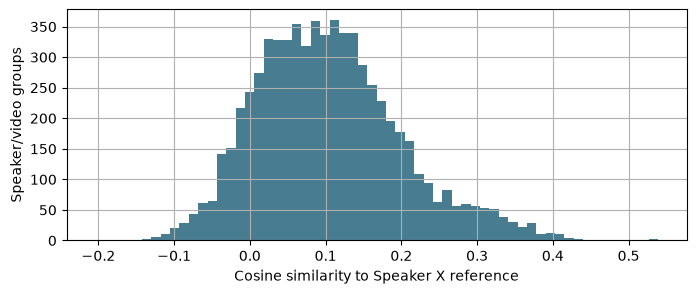

,channel,file,speaker,median_similarity,failed_rows
0,Yah_Lah_BUT,20220726--7xS2y_U0Bz4--The Woke Salaryman on t...,SPEAKER_02,0.539384,[]
1,Yah_Lah_BUT,20220726--K0KWltK4Pvg--The Woke Salaryman on w...,SPEAKER_03,0.536185,[]
2,Yah_Lah_BUT,20230130--NeV0shDHyw4--Matt Walsh praises SG’s...,SPEAKER_01,0.448016,[]
3,Yah_Lah_BUT,20230315--kBNGp8Pzwgs--Where is the Cheapest P...,SPEAKER_02,0.436731,[]
4,Yah_Lah_BUT,20230109--fbIEHYxAvog--Singapore kids not phys...,SPEAKER_01,0.435049,[]
5,Yah_Lah_BUT,20230912--iES2BRHUZRU--Ashton Kutcher and Mila...,SPEAKER_00,0.431929,[]
6,Yah_Lah_BUT,20221203--jk792k4a1v4--Should Trevor Noah Have...,SPEAKER_01,0.425710,[]
7,Yah_Lah_BUT,20210604--6bbd2r9hD0Y--Should Singapore cancel...,SPEAKER_00,0.422022,[]
8,The_Daily_Ketchup_Podcast,20231211--OYmDy_KQQaI--What This Russian Expat...,SPEAKER_00,0.421437,[]
9,Yah_Lah_BUT,20230214--dB2a5g8Vl8M--SG Cash-Only Businesses...,SPEAKER_01,0.416597,[]


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
scores = pd.read_json(OUTPUT / 'group-scores.jsonl', lines=True)
scores['median_similarity'].dropna().hist(bins=60, figsize=(8, 3), color='#477c91')
plt.xlabel('Cosine similarity to Speaker X reference')
plt.ylabel('Speaker/video groups')
plt.show()
scores[['channel', 'file', 'speaker', 'median_similarity', 'failed_rows']].head(25)


## Scope: YCSEP-Only Speaker Detection
Use the supplied reference and required pyannote/embedding model to identify Speaker X within YCSEP. Reuse YCSEP audio, within-video speaker labels and annotated start/end times. Do not download full YouTube recordings or run Sortformer re-diarization for this submission. YouTube title lookup is metadata only, not an additional audio dataset.

The localization assumption is that the selected YCSEP speaker label is consistent within its video and its annotated boundaries are accurate. Export those intervals in ascending order, merging only overlapping or touching intervals. This does not independently establish exact acoustic boundaries; label drift, overlaps and unscorable short groups remain limitations.

## Calibration and Localization Review
A fixed heuristic threshold of 0.49 lies between the two leading group scores (0.5394 and 0.5362) and the next score (0.4480). This is an unlabeled separation heuristic, not a calibrated probability or measured precision/recall. Sensitivity analysis yields three videos at 0.44, two at 0.49 and none at 0.54. The two selected recordings are related full-episode/excerpt material, not independent positive validation examples.

The first retrieval pass processed 16,972 representative clips in 62.9 minutes. Seventy-two groups contain only unscorable very short clips; these are unknown, not confirmed negatives. After classifying these failures, no retryable failures remained. Exports preserve all intervals of the selected within-video speaker labels, including intervals that overlap other speakers; only touching/overlapping selected intervals are merged. Complete speaker recall and acoustic boundary exactness are not established.

The following cell creates the requested prediction artifacts and validates their structure. These are the final outputs of the stated YCSEP-only method, not manually verified ground truth.

## Future Work
First label cross-recording positives and near-threshold negatives and evaluate precision/recall separately from threshold selection. Audit annotation drift and short unknown groups. Evaluate full-recording re-diarization with Sortformer as a separate experiment, then compare boundaries and overlapping-speaker coverage against manually annotated examples. These are proposed extensions, not implemented or validated results.

In [5]:
from export_detections import export
destination = ROOT / 'speaker-detection'
report = export(OUTPUT / 'group-scores.jsonl', destination, 0.49,
    'Unlabeled gap heuristic; no measured precision/recall; YCSEP annotation boundaries assumed.',
    title_cache=OUTPUT / 'title-provenance.json')
detections = json.loads((destination / 'detected_timestamps.json').read_text())
titles = (destination / 'detected_titles.txt').read_text().splitlines()
assert sorted(set(d['title'] for d in detections)) == titles
for video in detections:
    assert set(video) == {'title', 'segments'}
    previous_end = -1
    for segment in video['segments']:
        assert set(segment) == {'start_time', 'end_time'}
        assert 0 <= segment['start_time'] < segment['end_time']
        assert segment['start_time'] > previous_end
        previous_end = segment['end_time']
print({'videos': len(detections), 'segments': sum(len(d['segments']) for d in detections)})
report


{'videos': 2, 'segments': 795}


{'model': 'pyannote/embedding',
 'threshold': 0.49,
 'threshold_note': 'Unlabeled gap heuristic; no measured precision/recall; YCSEP annotation boundaries assumed.',
 'source_sha256': 'c3d2ec10e65fefc6763ecbecd3638170042905008ca7a83f675d4f367ad1d57a',
 'videos_detected': 2,
 'speaker_groups_selected': 2,
 'groups_searched': 6823,
 'unscorable_groups': 72,
 'unverified_titles': [],
 'boundary_source': 'YCSEP annotated speaker intervals; independently verified boundary accuracy unavailable',
 'interpretation': 'Threshold-based predictions, not a measured guarantee of complete speaker recall',
 'sensitivity_videos': {'0.44': 3, '0.49': 2, '0.54': 0}}

## Additional robustness audit
The same two predicted videos are selected across thresholds 0.46-0.52 and occupy the top two ranks across all 14 half-reference/leave-one-window-out variants. The original 6,751 scorable group scores were reproduced from cached embeddings. Each selected group has only two of three clips above 0.49. These are ranking-stability checks, not identity labels or measured precision/recall. Seventy-two groups remain unscorable; manual identity and boundary verification remain unresolved. No denoising or threshold change was introduced.


In [6]:
from pathlib import Path
import json
r=Path.cwd()
if not (r/'speaker-detection').exists(): r=r.parent
a=json.loads((r/'speaker-detection/results/reference-stability-audit.json').read_text())
print({v['variant']:v['original_selected_ranks'] for v in a['variants']})

{'first_half': [1, 2], 'second_half': [1, 2], 'omit_window_0': [1, 2], 'omit_window_1': [2, 1], 'omit_window_2': [1, 2], 'omit_window_3': [1, 2], 'omit_window_4': [2, 1], 'omit_window_5': [2, 1], 'omit_window_6': [1, 2], 'omit_window_7': [1, 2], 'omit_window_8': [1, 2], 'omit_window_9': [1, 2], 'omit_window_10': [1, 2], 'omit_window_11': [1, 2]}
